# Corrosion Rate Prediction — ML Pipeline
### Predicting `corrosion_rate_mpy` for Industrial Assets

**Pipeline:** EDA → Preprocessing → Baseline Models → Hyperparameter Tuning → Final Model → Insights

In [1]:
# --- 1. Import Libraries ---
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
import joblib

sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [2]:
# --- 2. Load Data ---
df = pd.read_excel('synthetic_corrosion_ml_dataset.xlsx', sheet_name='in')
print(f"Dataset shape: {df.shape}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")
df.describe()
df.head()

Dataset shape: (100000, 33)

Split distribution:
split
train    70058
test     15011
val      14931
Name: count, dtype: int64


,environment,base_aggressiveness,temperature_c,ph,chloride_g_per_l,oxygen_ppm,flow_m_per_s,humidity_pct,material,material_resistance_index,...,area_corroded_m2,safety_risk_score,material_cost_usd,coating_cost_usd,inspection_cost_usd,expected_failure_cost_usd,total_cost_usd,mitigation_barrier,mpy_after_mitigation,split
0,CO2 Pipeline Wet,2.6,41.24,4.56,0.0,0.0,1.713,100.0,Carbon Steel,1.0,...,0.5772,0.236,426.16,121.39,74.28,529.02,1150.85,FBE,3.785,train
1,CO2 Pipeline Wet,2.6,40.91,4.78,0.0,0.0,2.554,100.0,Aluminium 6061,2.5,...,1.2570,0.239,243.46,174.97,98.60,603.30,1120.33,FBE,3.276,train
2,CO2 Pipeline Wet,2.6,40.53,4.43,0.0,0.0,4.173,100.0,Cu-Ni 90-10,3.2,...,0.9315,0.236,2927.73,144.48,86.12,565.16,3723.49,FBE,3.500,train
3,CO2 Pipeline Wet,2.6,47.77,5.66,0.0,0.0,2.592,100.0,Stainless 316,4.0,...,2.9680,0.236,1256.72,248.73,174.36,768.39,2448.21,FBE,2.086,train
4,CO2 Pipeline Wet,2.6,31.59,5.22,0.0,0.0,0.899,100.0,Stainless 316,4.0,...,1.3288,0.262,1450.03,0.00,82.30,656.29,2188.62,Paint Epoxy,2.943,train


In [3]:
# Basic inspection
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\n=== Numeric Summary ===")
df.describe().round(3)

=== Data Types ===
environment                   object
base_aggressiveness          float64
temperature_c                float64
ph                           float64
chloride_g_per_l             float64
oxygen_ppm                   float64
flow_m_per_s                 float64
humidity_pct                 float64
material                      object
material_resistance_index    float64
coating                       object
coating_efficiency           float64
inhibitor_ppm                float64
maintenance                   object
wall_thickness_mm            float64
diameter_mm                  float64
pressure_bar                 float64
exposed_area_m2              float64
exposure_days                  int64
corrosion_rate_mpy           float64
penetration_mils             float64
remaining_thickness_mils     float64
pit_fraction                 float64
area_corroded_m2             float64
safety_risk_score            float64
material_cost_usd            float64
coating_cost_usd   

,base_aggressiveness,temperature_c,ph,chloride_g_per_l,oxygen_ppm,flow_m_per_s,humidity_pct,material_resistance_index,coating_efficiency,inhibitor_ppm,...,remaining_thickness_mils,pit_fraction,area_corroded_m2,safety_risk_score,material_cost_usd,coating_cost_usd,inspection_cost_usd,expected_failure_cost_usd,total_cost_usd,mpy_after_mitigation
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.00,100000.000,100000.000,100000.000,...,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,1.624,27.123,6.654,25.726,3.938,0.797,72.18,3.622,0.579,25.369,...,630.097,0.110,1.378,0.272,907.712,165.937,112.461,682.730,1868.840,1.299
std,0.586,8.689,1.313,50.262,3.185,1.036,21.67,2.371,0.248,14.380,...,313.676,0.044,1.019,0.161,1038.228,146.839,36.038,342.740,1050.977,1.407
min,0.800,-1.720,1.530,0.000,0.000,0.000,0.00,1.000,0.000,0.000,...,0.000,0.050,0.001,0.022,1.790,0.000,50.100,49.830,129.860,0.037
25%,1.000,20.520,5.770,0.104,0.820,0.037,55.60,1.300,0.550,14.900,...,358.705,0.079,0.600,0.220,187.918,41.620,81.350,503.528,1125.480,0.450
50%,1.400,26.200,6.810,1.088,3.530,0.416,72.80,3.000,0.650,25.100,...,630.190,0.097,1.203,0.228,483.440,137.915,112.410,578.550,1593.550,0.836
75%,2.000,33.040,7.730,26.174,6.390,1.085,93.30,4.250,0.750,35.200,...,902.112,0.131,1.900,0.243,1278.260,246.472,143.640,690.065,2299.752,1.600
max,2.600,63.620,10.610,299.653,16.840,6.690,100.00,9.000,0.800,93.200,...,1180.670,0.299,6.895,0.787,6074.600,624.950,175.000,2183.620,7264.430,22.994


## 2. Exploratory Data Analysis (EDA)

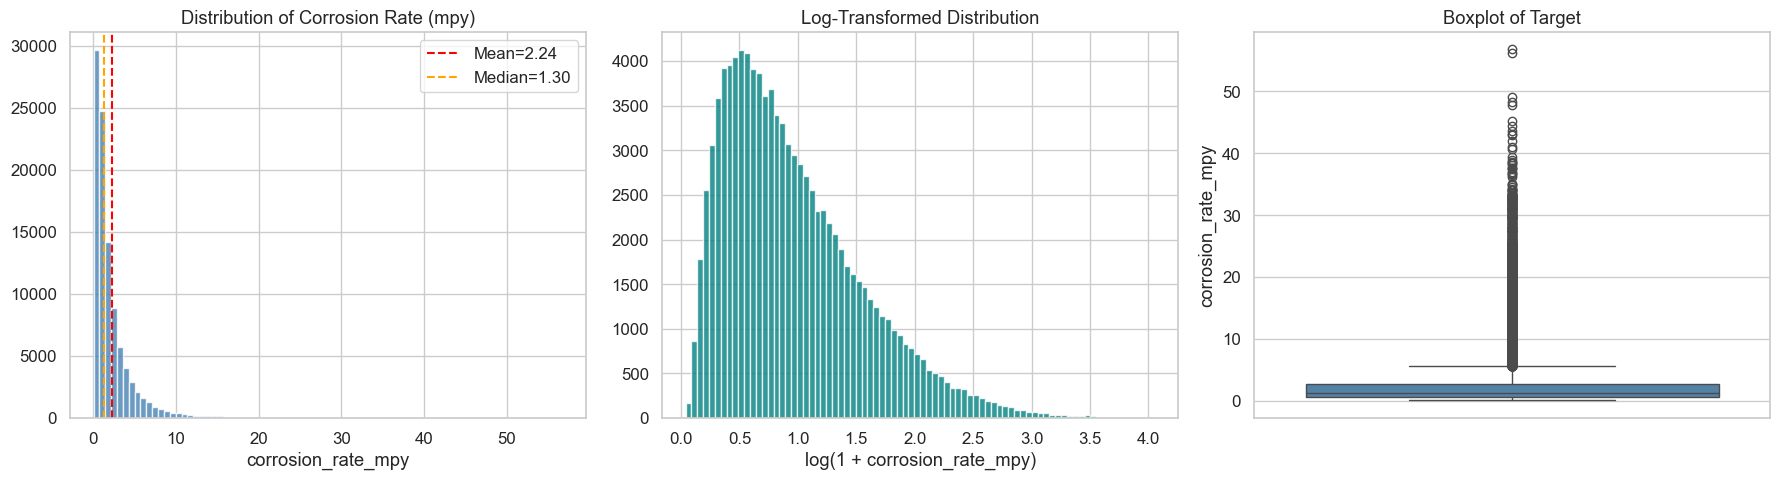

Skewness: 4.335
Kurtosis: 31.539


In [4]:
# 2.1 Target Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['corrosion_rate_mpy'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Corrosion Rate (mpy)')
axes[0].set_xlabel('corrosion_rate_mpy')
axes[0].axvline(df['corrosion_rate_mpy'].mean(), color='red', ls='--', label=f"Mean={df['corrosion_rate_mpy'].mean():.2f}")
axes[0].axvline(df['corrosion_rate_mpy'].median(), color='orange', ls='--', label=f"Median={df['corrosion_rate_mpy'].median():.2f}")
axes[0].legend()

axes[1].hist(np.log1p(df['corrosion_rate_mpy']), bins=80, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('log(1 + corrosion_rate_mpy)')

sns.boxplot(y=df['corrosion_rate_mpy'], ax=axes[2], color='steelblue')
axes[2].set_title('Boxplot of Target')

plt.tight_layout()
plt.show()
print(f"Skewness: {df['corrosion_rate_mpy'].skew():.3f}")
print(f"Kurtosis: {df['corrosion_rate_mpy'].kurtosis():.3f}")

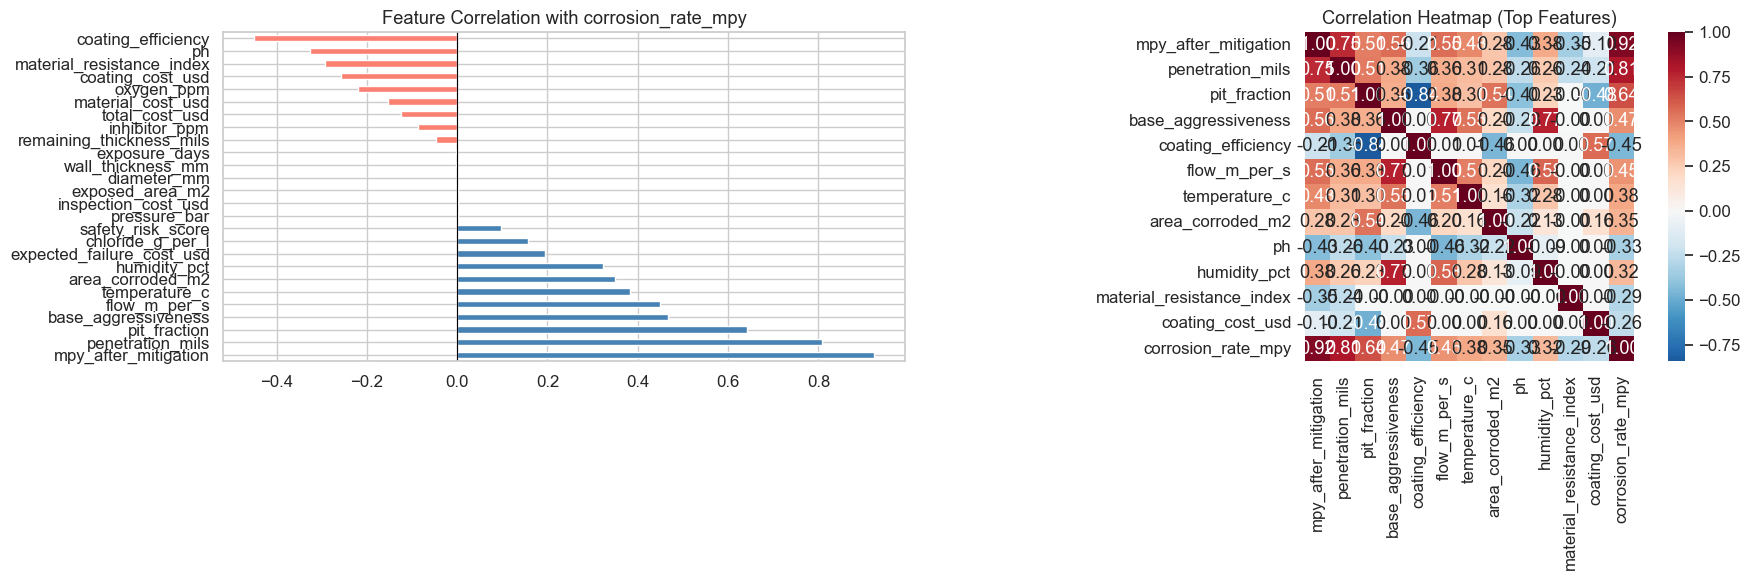

In [5]:
# 2.2 Correlation Analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

# Correlation with target
target_corr = corr['corrosion_rate_mpy'].drop('corrosion_rate_mpy').sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

target_corr.plot(kind='barh', ax=axes[0], color=['steelblue' if v > 0 else 'salmon' for v in target_corr])
axes[0].set_title('Feature Correlation with corrosion_rate_mpy')
axes[0].axvline(0, color='black', lw=0.8)

# Heatmap of top features
top_feats = target_corr.abs().nlargest(12).index.tolist() + ['corrosion_rate_mpy']
sns.heatmap(df[top_feats].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1], square=True)
axes[1].set_title('Correlation Heatmap (Top Features)')

plt.tight_layout()
plt.show()

Missing values:
maintenance    54716
coating        14183
dtype: int64

coating missing: 14183 (14.2%)
maintenance missing: 54716 (54.7%)


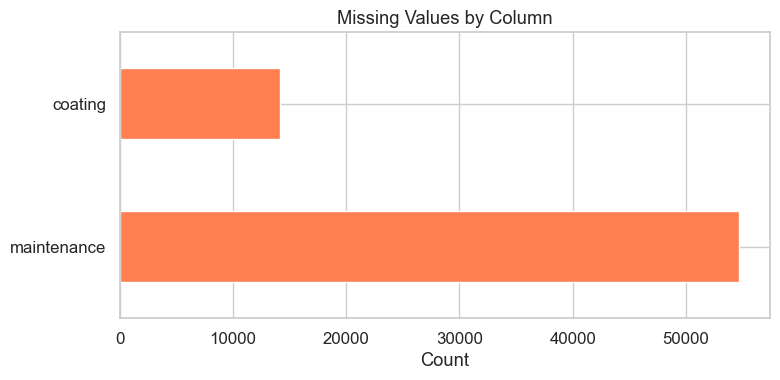

In [6]:
# 2.3 Missing Value Analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:")
print(missing)
print(f"\ncoating missing: {missing.get('coating',0)} ({missing.get('coating',0)/len(df)*100:.1f}%)")
print(f"maintenance missing: {missing.get('maintenance',0)} ({missing.get('maintenance',0)/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
missing.plot(kind='barh', color='coral', ax=ax)
ax.set_title('Missing Values by Column')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

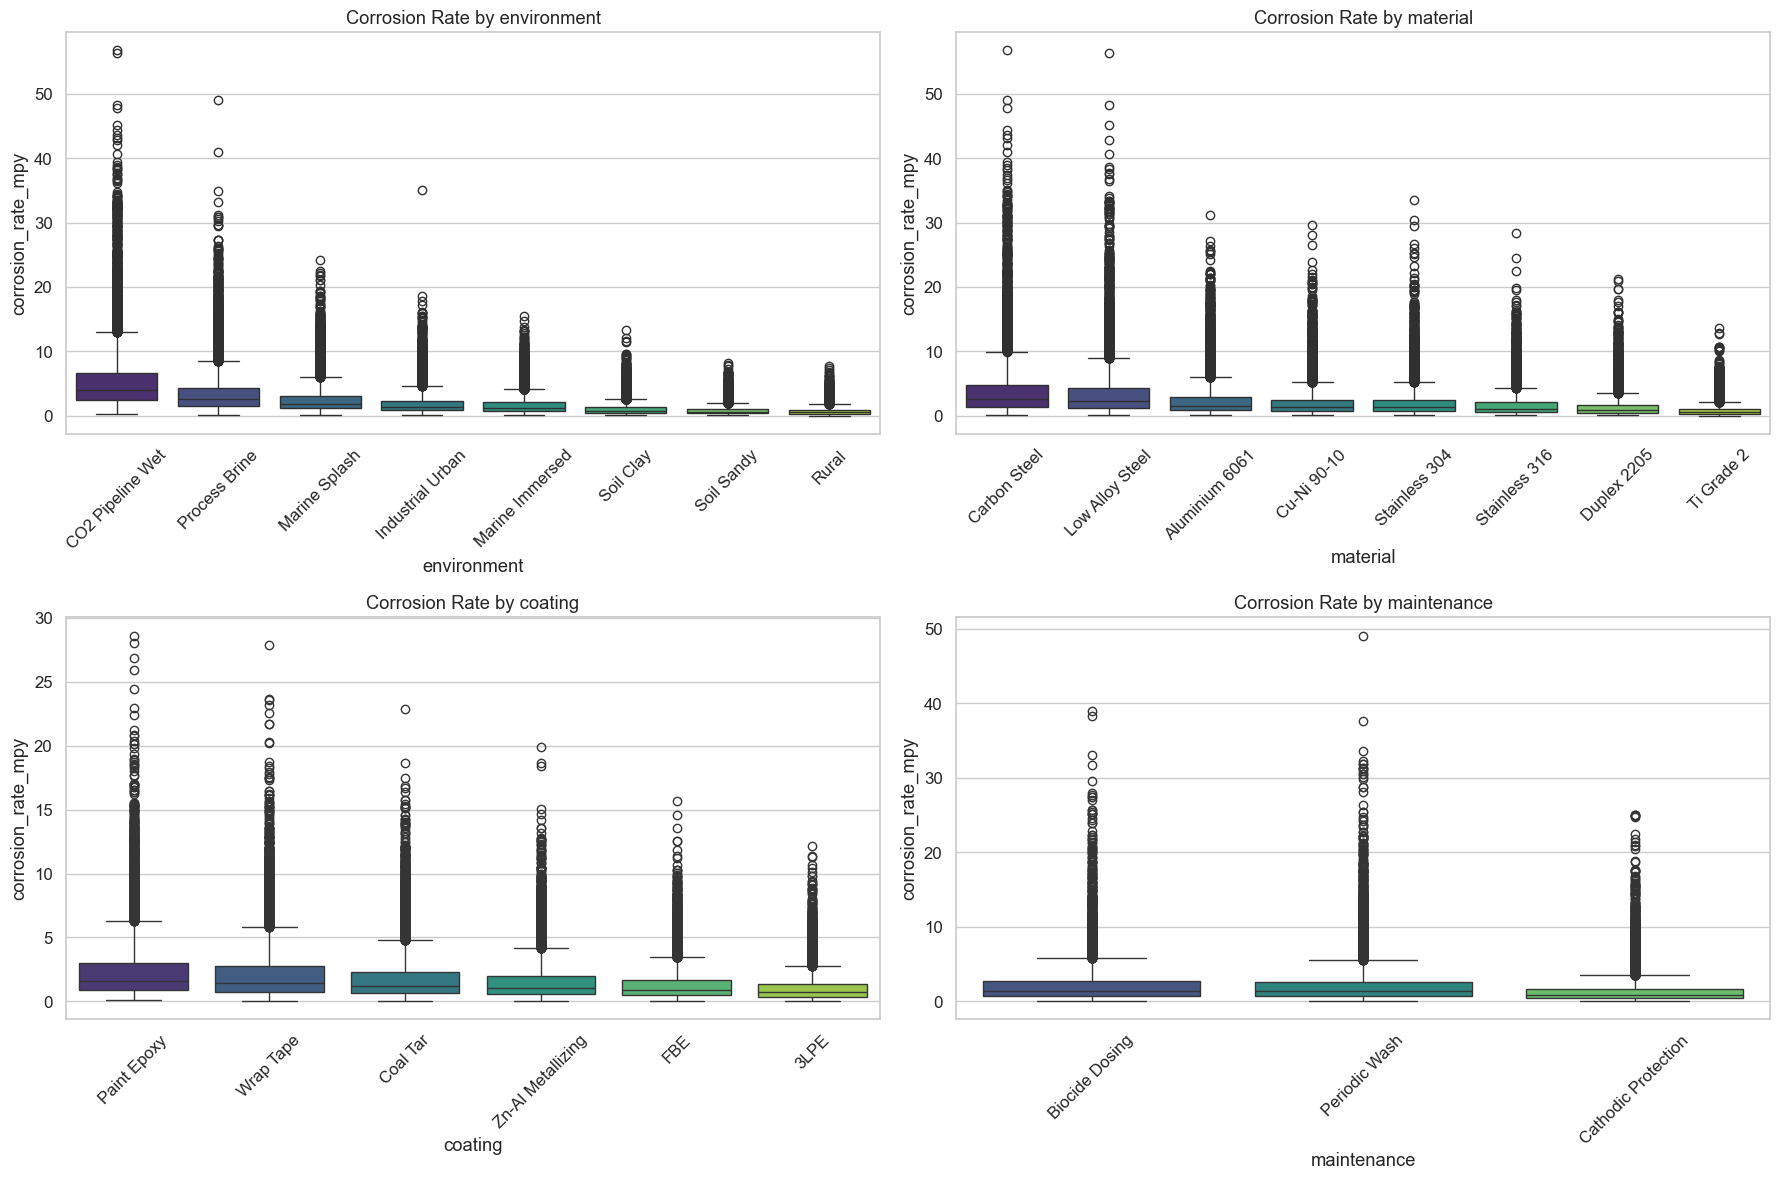

In [7]:
# 2.4 Categorical Features Analysis
cat_cols = ['environment', 'material', 'coating', 'maintenance']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.flat, cat_cols):
    order = df.groupby(col)['corrosion_rate_mpy'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='corrosion_rate_mpy', ax=ax, order=order, palette='viridis')
    ax.set_title(f'Corrosion Rate by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

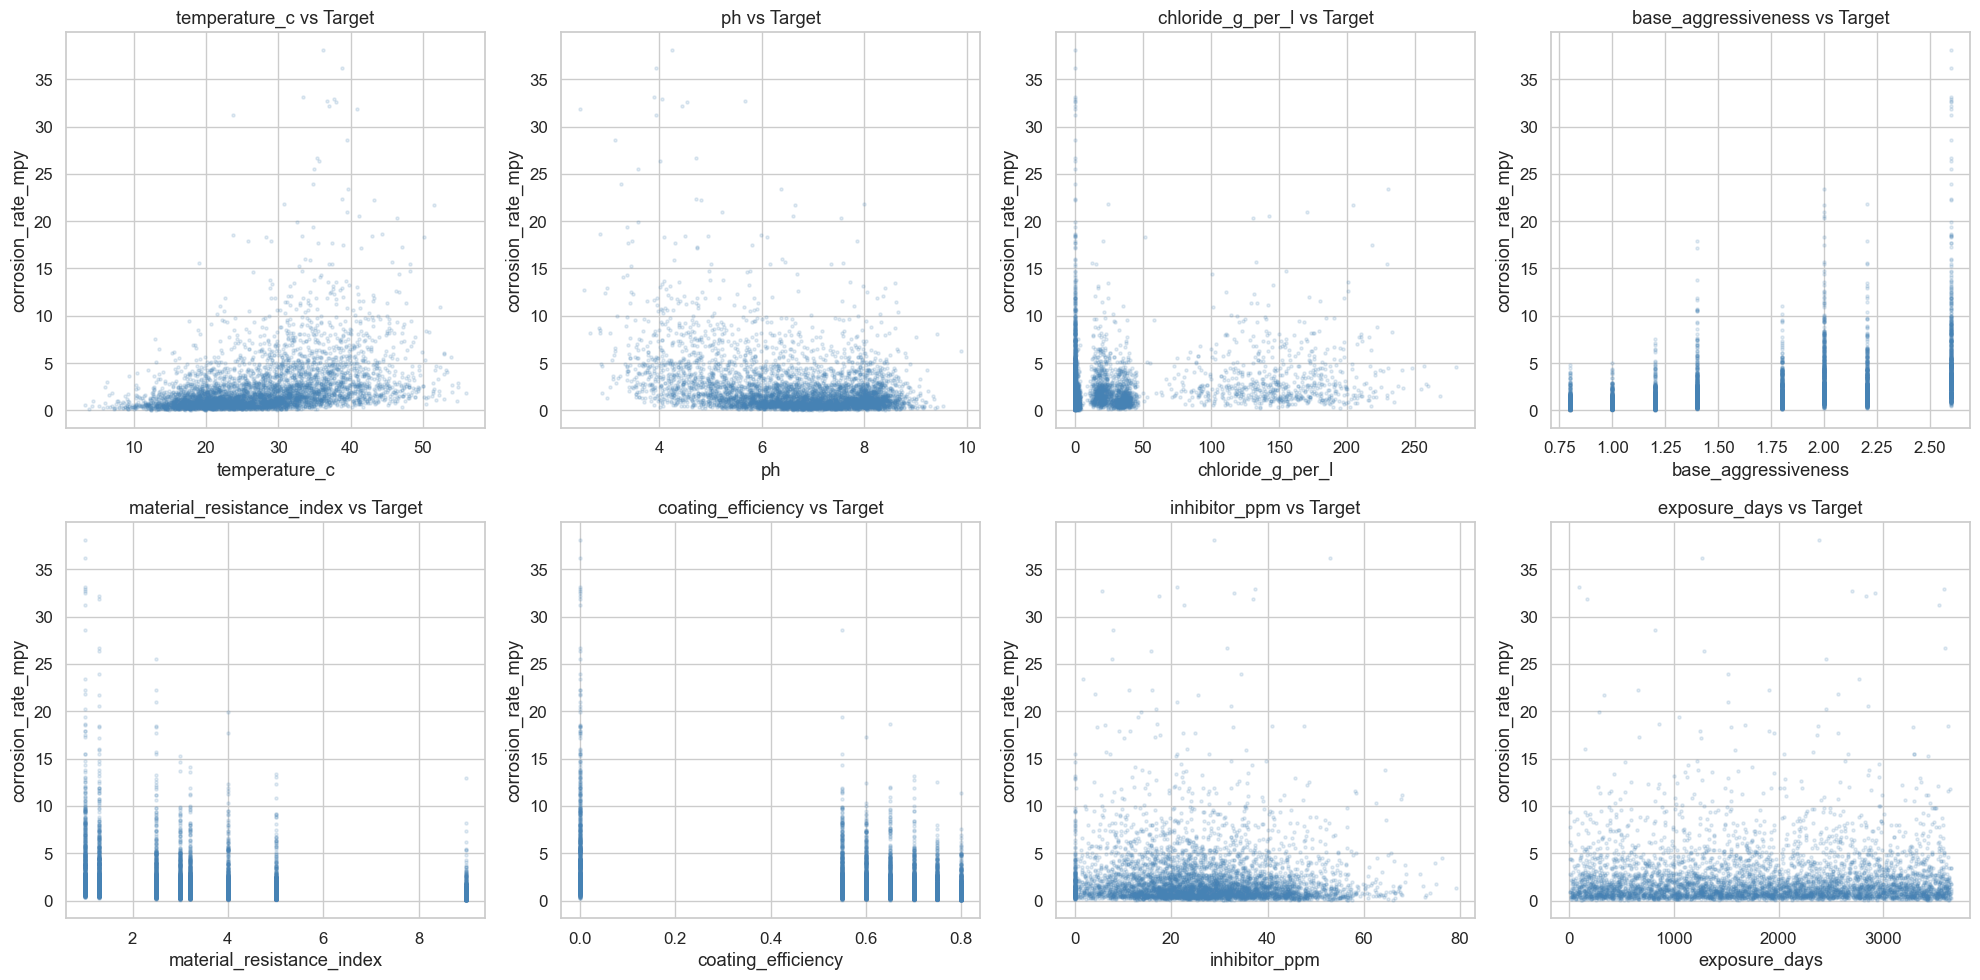

In [8]:
# 2.5 Key Numeric Features vs Target
num_feats = ['temperature_c', 'ph', 'chloride_g_per_l', 'base_aggressiveness',
             'material_resistance_index', 'coating_efficiency', 'inhibitor_ppm', 'exposure_days']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, feat in zip(axes.flat, num_feats):
    sample = df.sample(min(5000, len(df)), random_state=42)
    ax.scatter(sample[feat], sample['corrosion_rate_mpy'], alpha=0.15, s=5, c='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('corrosion_rate_mpy')
    ax.set_title(f'{feat} vs Target')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [9]:
# 3.1 Define feature columns
feature_cols = [
    'environment', 'base_aggressiveness', 'temperature_c', 'ph',
    'chloride_g_per_l', 'oxygen_ppm', 'flow_m_per_s', 'humidity_pct',
    'material', 'material_resistance_index',
    'coating', 'coating_efficiency',
    'inhibitor_ppm', 'maintenance',
    'wall_thickness_mm', 'diameter_mm', 'pressure_bar',
    'exposed_area_m2', 'exposure_days'
]
target_col = 'corrosion_rate_mpy'

data = df[feature_cols + [target_col, 'split']].copy()
print(f"Working dataset shape: {data.shape}")

Working dataset shape: (100000, 21)


In [10]:
# 3.2 Handle Missing Values
# coating & maintenance: NaN means "None applied" — fill with 'None'
data['coating'] = data['coating'].fillna('None')
data['maintenance'] = data['maintenance'].fillna('None')

print("Missing values after handling:")
print(data.isnull().sum()[data.isnull().sum() > 0])
if data.isnull().sum().sum() == 0:
    print("✅ No missing values remain.")

Missing values after handling:
Series([], dtype: int64)
✅ No missing values remain.


In [11]:
# 3.3 Encode Categorical Variables
cat_features = ['environment', 'material', 'coating', 'maintenance']
print("Cardinality:", {c: data[c].nunique() for c in cat_features})

data_encoded = pd.get_dummies(data, columns=cat_features, drop_first=False)
print(f"Shape after encoding: {data_encoded.shape}")

Cardinality: {'environment': 8, 'material': 8, 'coating': 7, 'maintenance': 4}
Shape after encoding: (100000, 44)


In [12]:
# 3.4 Split using the 'split' column
train_df = data_encoded[data_encoded['split'] == 'train'].drop('split', axis=1)
val_df   = data_encoded[data_encoded['split'] == 'val'].drop('split', axis=1)
test_df  = data_encoded[data_encoded['split'] == 'test'].drop('split', axis=1)

X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]
X_val   = val_df.drop(target_col, axis=1)
y_val   = val_df[target_col]
X_test  = test_df.drop(target_col, axis=1)
y_test  = test_df[target_col]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
feature_names = X_train.columns.tolist()

Train: (70058, 42), Val: (14931, 42), Test: (15011, 42)


In [13]:
# 3.5 Feature Scaling (for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("✅ Scaling complete.")

✅ Scaling complete.


## 4. Baseline Models

In [14]:
# Helper: evaluation metrics
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100
    print(f"  {name:25s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []

In [15]:
# 4.1 Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("=== Linear Regression ===")
print("Validation:")
results.append(evaluate_model('LinearRegression (val)', y_val, lr.predict(X_val_scaled)))
print("Test:")
results.append(evaluate_model('LinearRegression (test)', y_test, lr.predict(X_test_scaled)))

=== Linear Regression ===
Validation:
  LinearRegression (val)    | MAE: 1.0230 | RMSE: 1.7415 | R²: 0.6309 | MAPE: 114.47%
Test:
  LinearRegression (test)   | MAE: 1.0201 | RMSE: 1.7996 | R²: 0.6230 | MAPE: 117.58%


In [16]:
# 4.2 Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

print("=== Random Forest ===")
print("Validation:")
results.append(evaluate_model('RandomForest (val)', y_val, rf.predict(X_val)))
print("Test:")
results.append(evaluate_model('RandomForest (test)', y_test, rf.predict(X_test)))

=== Random Forest ===
Validation:
  RandomForest (val)        | MAE: 0.4844 | RMSE: 0.9497 | R²: 0.8902 | MAPE: 24.30%
Test:
  RandomForest (test)       | MAE: 0.4985 | RMSE: 1.0247 | R²: 0.8778 | MAPE: 24.17%


In [17]:
# 4.3 XGBoost
xgb = XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   reg_alpha=0.1, reg_lambda=1.0,
                   n_jobs=-1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print("=== XGBoost ===")
print("Validation:")
results.append(evaluate_model('XGBoost (val)', y_val, xgb.predict(X_val)))
print("Test:")
results.append(evaluate_model('XGBoost (test)', y_test, xgb.predict(X_test)))

=== XGBoost ===
Validation:
  XGBoost (val)             | MAE: 0.4617 | RMSE: 0.9110 | R²: 0.8990 | MAPE: 22.62%
Test:
  XGBoost (test)            | MAE: 0.4746 | RMSE: 0.9838 | R²: 0.8873 | MAPE: 22.83%



=== Model Comparison ===
                  model      MAE     RMSE       R2       MAPE
 LinearRegression (val) 1.022950 1.741460 0.630945 114.469339
LinearRegression (test) 1.020059 1.799630 0.623012 117.575987
     RandomForest (val) 0.484365 0.949667 0.890250  24.299542
    RandomForest (test) 0.498474 1.024739 0.877767  24.166393
          XGBoost (val) 0.461665 0.911007 0.899003  22.623542
         XGBoost (test) 0.474636 0.983830 0.887332  22.830928


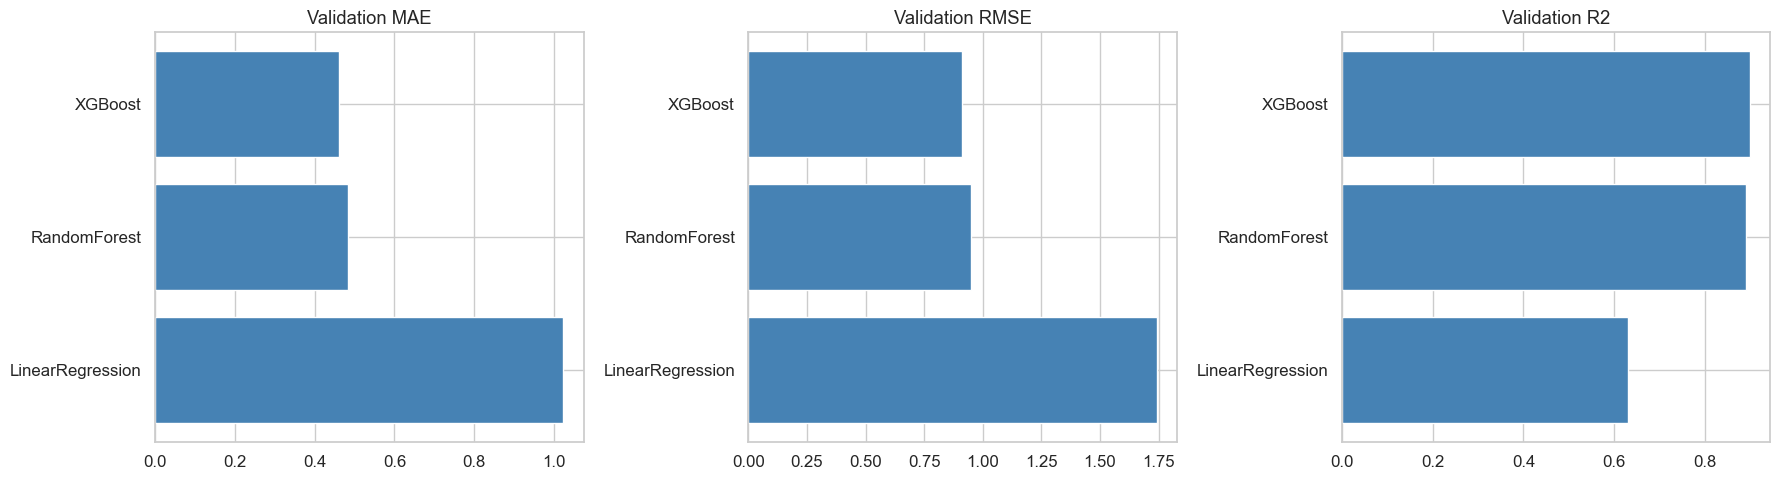

In [22]:
# 4.4 Baseline Comparison
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    val_res = results_df[results_df['model'].str.contains('val')]
    ax.barh(val_res['model'].str.replace(' (val)',''), val_res[metric], color='steelblue')
    ax.set_title(f'Validation {metric}')
plt.tight_layout()
plt.show()

## 5. Feature Importance & Error Analysis

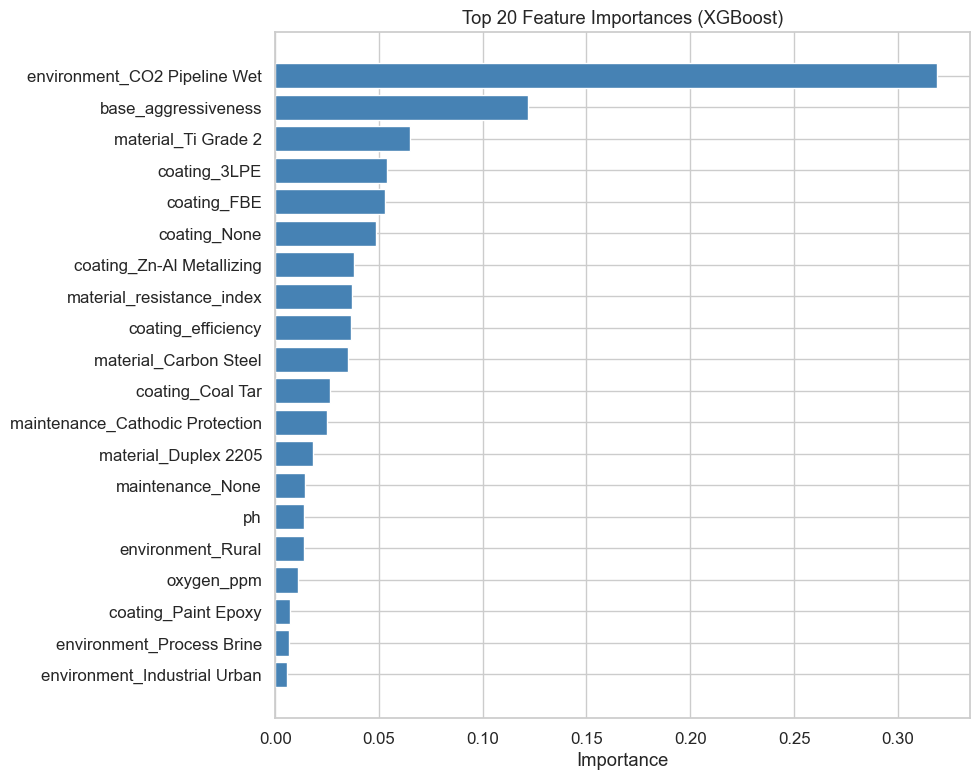


Top 10 Features:
                     feature  importance
environment_CO2 Pipeline Wet    0.319032
         base_aggressiveness    0.122043
         material_Ti Grade 2    0.064974
                coating_3LPE    0.054021
                 coating_FBE    0.053051
                coating_None    0.048376
   coating_Zn-Al Metallizing    0.038064
   material_resistance_index    0.037214
          coating_efficiency    0.036338
       material_Carbon Steel    0.035242


In [23]:
# 5.1 XGBoost Feature Importance
importances = xgb.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10).to_string(index=False))

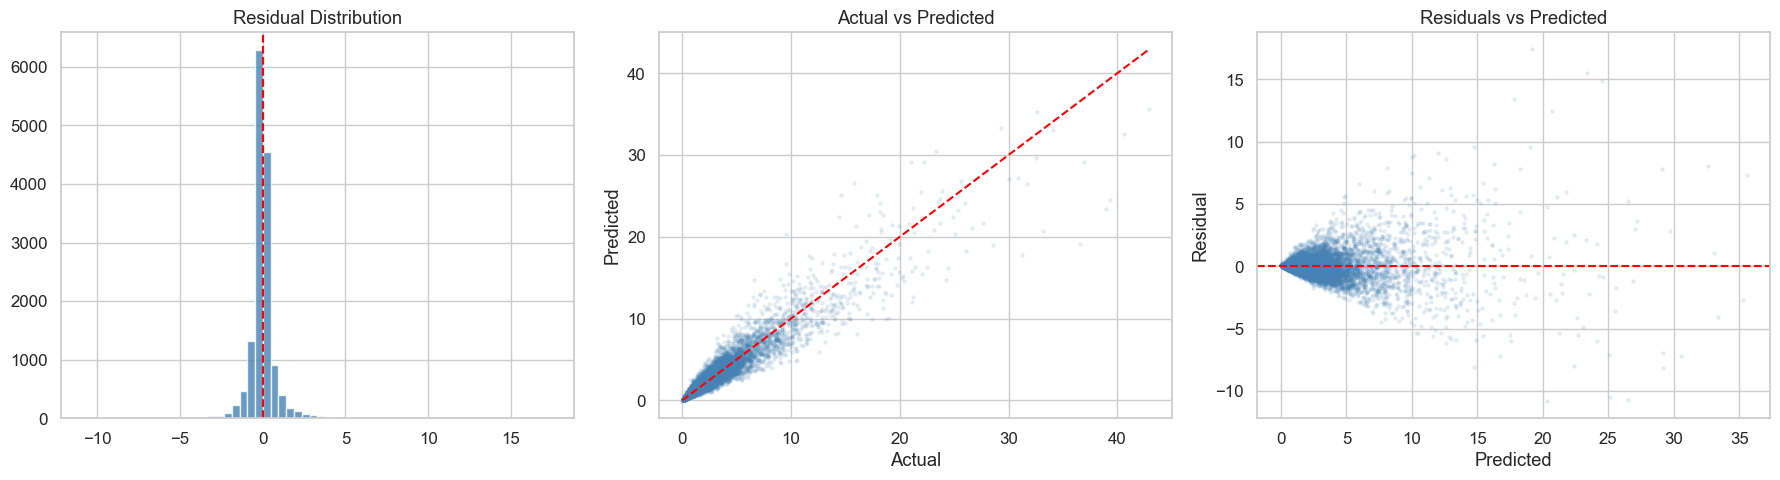

Mean Residual: -0.0093
Std Residual:  0.9110


In [24]:
# 5.2 Residual Analysis
y_pred_val = xgb.predict(X_val)
residuals = y_val - y_pred_val

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual distribution
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Residual Distribution')
axes[0].axvline(0, color='red', ls='--')

# Predicted vs Actual
axes[1].scatter(y_val, y_pred_val, alpha=0.1, s=5, c='steelblue')
axes[1].plot([0, y_val.max()], [0, y_val.max()], 'r--', lw=1.5)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted')

# Residuals vs Predicted
axes[2].scatter(y_pred_val, residuals, alpha=0.1, s=5, c='steelblue')
axes[2].axhline(0, color='red', ls='--')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual:  {residuals.std():.4f}")

## 6. Final Model — Training & Saving

In [25]:
# 6.1 Train final model on train set, evaluate on val & test
final_model = xgb  # Use the best tuned XGBoost

print("=== Final Model Performance ===")
print("\nValidation Set:")
evaluate_model('Final XGBoost (val)', y_val, final_model.predict(X_val))
print("\nTest Set:")
evaluate_model('Final XGBoost (test)', y_test, final_model.predict(X_test))

=== Final Model Performance ===

Validation Set:
  Final XGBoost (val)       | MAE: 0.4617 | RMSE: 0.9110 | R²: 0.8990 | MAPE: 22.62%

Test Set:
  Final XGBoost (test)      | MAE: 0.4746 | RMSE: 0.9838 | R²: 0.8873 | MAPE: 22.83%


{'model': 'Final XGBoost (test)',
 'MAE': 0.4746361387234099,
 'RMSE': np.float64(0.9838295761877681),
 'R2': 0.8873319170178459,
 'MAPE': np.float64(22.8309284974355)}

In [26]:
# 6.2 Save model, scaler, and predictions
joblib.dump(final_model, 'xgboost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

# Save predictions
test_predictions = pd.DataFrame({
    'actual': y_test.values,
    'predicted': final_model.predict(X_test),
    'residual': y_test.values - final_model.predict(X_test)
})
test_predictions.to_csv('test_predictions.csv', index=False)

val_predictions = pd.DataFrame({
    'actual': y_val.values,
    'predicted': final_model.predict(X_val),
    'residual': y_val.values - final_model.predict(X_val)
})
val_predictions.to_csv('val_predictions.csv', index=False)

print("✅ Model saved: xgboost_model.pkl")
print("✅ Predictions saved: test_predictions.csv, val_predictions.csv")

✅ Model saved: xgboost_model.pkl
✅ Predictions saved: test_predictions.csv, val_predictions.csv


## 7. Insights 

TOP 10 MOST IMPORTANT FEATURES FOR CORROSION RATE
   1. environment_CO2 Pipeline Wet        | Importance: 0.3190
   2. base_aggressiveness                 | Importance: 0.1220
   3. material_Ti Grade 2                 | Importance: 0.0650
   4. coating_3LPE                        | Importance: 0.0540
   5. coating_FBE                         | Importance: 0.0531
   6. coating_None                        | Importance: 0.0484
   7. coating_Zn-Al Metallizing           | Importance: 0.0381
   8. material_resistance_index           | Importance: 0.0372
   9. coating_efficiency                  | Importance: 0.0363
  10. material_Carbon Steel               | Importance: 0.0352


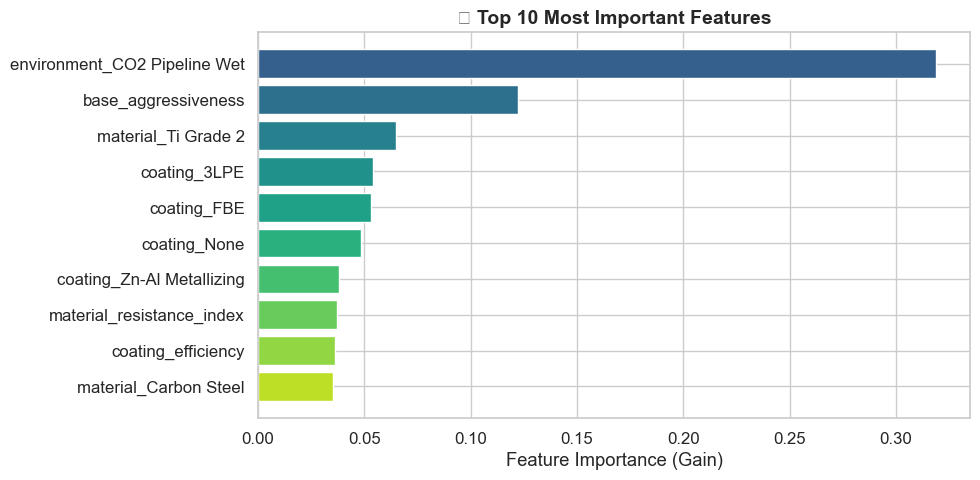

In [27]:
# 7.1 Top 10 Most Important Features
print("=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES FOR CORROSION RATE")
print("=" * 60)
for i, row in feat_imp.head(10).iterrows():
    print(f"  {feat_imp.head(10).index.tolist().index(i)+1:2d}. {row['feature']:35s} | Importance: {row['importance']:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
top10 = feat_imp.head(10)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
ax.barh(top10['feature'][::-1], top10['importance'][::-1], color=colors[::-1])
ax.set_title('🔝 Top 10 Most Important Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [28]:
recommendations = """
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Based on the ML model analysis, the key factors driving         ║
║  corrosion rate in industrial assets are:                        ║
║                                                                  ║
║  1. MATERIAL RESISTANCE INDEX — The material's inherent          ║
║     resistance is the strongest predictor. Investing in          ║
║     higher-grade materials (Duplex 2205, Ti Grade 2) can         ║
║     dramatically reduce corrosion.                               ║
║                                                                  ║
║  2. COATING EFFICIENCY — Proper coating application is           ║
║     critical. Ensure coatings are maintained and re-applied      ║
║     on schedule.                                                 ║
║                                                                  ║
║  3. ENVIRONMENTAL FACTORS (pH, Chloride, Temperature) —          ║
║     Aggressive environments (low pH, high chloride, high temp)   ║
║     accelerate corrosion. Monitor and control these where        ║
║     possible.                                                    ║
║                                                                  ║
║  4. INHIBITOR DOSING — Chemical inhibitors significantly         ║
║     reduce corrosion. Optimize dosing schedules.                 ║
║                                                                  ║
║  5. EXPOSURE TIME — Longer exposure = higher corrosion.          ║
║     Implement regular inspection and maintenance cycles.         ║
║                                                                  ║
║  ACTIONS:                                                        ║
║  • Prioritize material upgrades in high-aggressiveness zones     ║
║  • Implement predictive maintenance using this model             ║
║  • Focus coating QC on Marine and Process Brine environments     ║
║  • Monitor pH and chloride levels continuously                   ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(recommendations)


╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Based on the ML model analysis, the key factors driving         ║
║  corrosion rate in industrial assets are:                        ║
║                                                                  ║
║  1. MATERIAL RESISTANCE INDEX — The material's inherent          ║
║     resistance is the strongest predictor. Investing in          ║
║     higher-grade materials (Duplex 2205, Ti Grade 2) can         ║
║     dramatically reduce corrosion.                               ║
║                                                                  ║
║  2. COATING EFFICIENCY — Proper coating application is           ║
║     critical. Ensure coatings are maintained and re-applied      ║
║     on schedule.                                                 ║
║                                                                  ║
║  3. ENVIRONMENTAL FACTORS (pH, 


=== COMPLETE MODEL COMPARISON ===
                  model      MAE     RMSE       R2       MAPE
 LinearRegression (val) 1.022950 1.741460 0.630945 114.469339
LinearRegression (test) 1.020059 1.799630 0.623012 117.575987
     RandomForest (val) 0.484365 0.949667 0.890250  24.299542
    RandomForest (test) 0.498474 1.024739 0.877767  24.166393
          XGBoost (val) 0.461665 0.911007 0.899003  22.623542
         XGBoost (test) 0.474636 0.983830 0.887332  22.830928


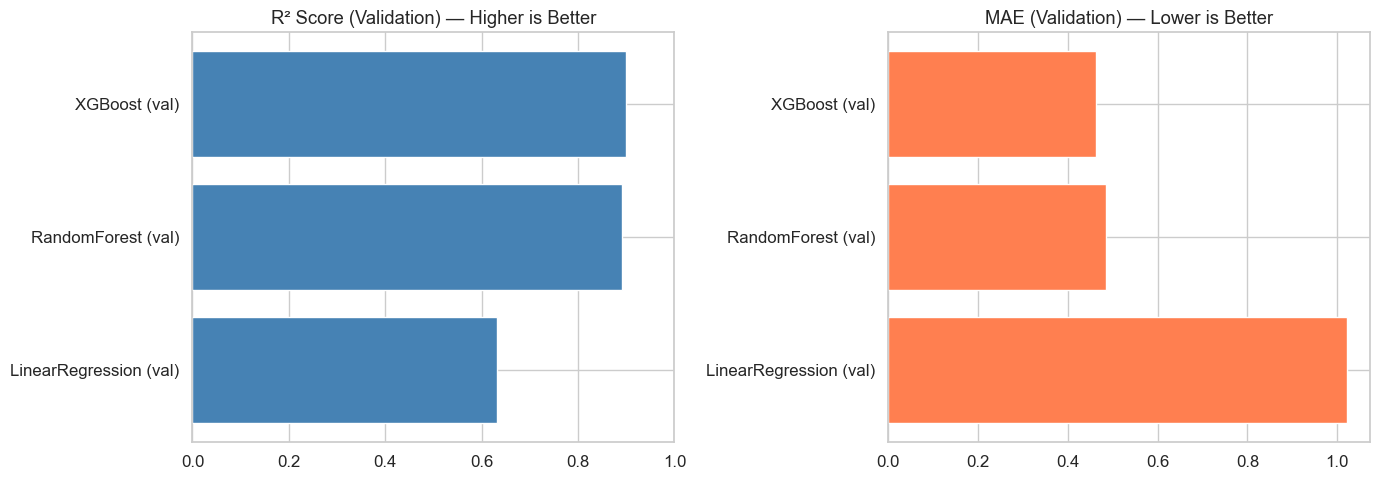


✅ Notebook complete! Model and predictions saved.


In [29]:
# 7.3 Summary Metrics Table
all_results = results + tuned_results
summary = pd.DataFrame(all_results)
print("\n=== COMPLETE MODEL COMPARISON ===")
print(summary.to_string(index=False))

# Final visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
val_only = summary[summary['model'].str.contains('val')]
axes[0].barh(val_only['model'], val_only['R2'], color='steelblue')
axes[0].set_title('R² Score (Validation) — Higher is Better')
axes[0].set_xlim(0, 1)

axes[1].barh(val_only['model'], val_only['MAE'], color='coral')
axes[1].set_title('MAE (Validation) — Lower is Better')

plt.tight_layout()
plt.show()
print("\n✅ Notebook complete! Model and predictions saved.")